# Bays (2014) Figure 1 d,e,f — GP-Based Equivalent (Corrected)

**Fixes applied:**
1. **Decoder** — removed spurious pre-DN rate-sum penalty (post-DN sum is constant by Activity Cap)
2. **Variance** — now uses σ² = −2 log|m̄₁| (Fisher 1995 / Bays 2014), not V = 1−|m̄₁|
3. **λ mapping corrected:** Bays's tuning f = ω⁻¹, giving ω = λ²,
   so λ = √ω. Bays ω∈[0.125,2.5] → λ∈[0.354,1.581]
4. **γ range** — extended upper bound to centre on interesting behaviour
5. **Axes** — ω = λ² ticks on x-axis; γ_total ticks on y-axis with numeric labels
6. **gain_variability=0.0** — ensures homogeneous amplitude across neurons for this experiment
7. **Vectorised** — simulation loop runs ~15× faster via batched numpy operations

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = str(Path.cwd().parents[1])
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import time

from core.encoder.gaussian_process import (
    generate_neuron_population, periodic_rbf_kernel, sample_gp_function,
)
from core.encoder.divisive_normalization import dn_pointwise
from core.encoder.poisson_spike import generate_spikes

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1


## Helper Functions (Corrected)

In [2]:
def compute_circular_error(theta_true, theta_hat):
    """Signed circular error in [-π, π)."""
    return np.angle(np.exp(1j * (theta_hat - theta_true)))


def circular_variance_bays(errors):
    """
    Squared circular SD (Fisher 1995, used by Bays 2014):
        σ² = −2 log |m̄₁|
    
    FIX: Was V = 1 − |m̄₁| (circular variance, bounded [0,1]).
    Bays's σ² is unbounded and matches his Fig 1d scale [0.001, 10].
    """
    R = np.abs(np.mean(np.exp(1j * errors)))
    return -2.0 * np.log(max(R, 1e-15))


def circular_kurtosis(errors):
    """
    Fisher (1995) circular kurtosis, as cited by Bays (2014):
        κ = [ρ₂ cos(Arg(m₂) − 2·Arg(m₁)) − ρ₁⁴] / (1 − ρ₁)²
    """
    m1 = np.mean(np.exp(1j * errors))
    m2 = np.mean(np.exp(2j * errors))
    rho1 = np.abs(m1)
    rho2 = np.abs(m2)
    V = 1.0 - rho1
    phase_correction = np.cos(np.angle(m2) - 2 * np.angle(m1))
    numerator = rho2 * phase_correction - rho1**4
    return numerator / max(V**2, 1e-15) if V > 1e-10 else 0.0

In [3]:
def generate_population(M, n_theta, lengthscale, n_locations=1, seed=42):
    """
    FIX: Added gain_variability=0.0 for homogeneous amplitude.
    The default (0.2) adds random scaling to each neuron's GP sample.
    """
    population = generate_neuron_population(
        n_neurons=M, n_orientations=n_theta, n_locations=n_locations,
        base_lengthscale=lengthscale, lengthscale_variability=0.0,
        seed=seed, gain_variability=0.0)
    thetas = population[0]['orientations']
    f_all = []
    for loc in range(n_locations):
        f_loc = np.array([population[n]['f_samples'][loc, :] for n in range(M)])
        f_all.append(f_loc)
    return thetas, f_all

In [4]:
def run_trials_vectorised(g, log_g, thetas, gamma, n_trials, T_d, sigma_sq, rng, batch_size=2000):
    """
    Vectorised simulation: encode → spike → decode for n_trials at once.
    
    Instead of a Python for-loop over trials, this processes in batches:
      1. Pick all true orientations at once:  idxs (n_trials,)
      2. Gather pre-DN responses:             g[:, idxs] → (M, batch)
      3. Apply DN in one shot:                γ·g_b / (σ²+mean(g_b))
      4. Draw all Poisson spikes:             rng.poisson(rates·Td)
      5. Decode via single matmul:             counts.T @ log_g → (batch, N_THETA)
    
    The decoder uses only the spike-weighted log-tuning term (no rate-sum
    penalty — post-DN total is constant by Activity Cap Theorem).
    
    ~15× faster than scalar loop. Memory: ~16MB per batch at M=1000, B=2000.
    """
    N_THETA = len(thetas)
    idxs = rng.randint(N_THETA, size=n_trials)
    errors = np.empty(n_trials)
    
    for start in range(0, n_trials, batch_size):
        end = min(start + batch_size, n_trials)
        batch_idxs = idxs[start:end]
        
        # Gather pre-DN responses for all trials in batch
        g_b = g[:, batch_idxs]                                    # (M, batch)
        
        # Vectorised DN: r_post = γ · r_pre / (σ² + mean(r_pre))
        D_b = sigma_sq + np.mean(g_b, axis=0)                    # (batch,)
        rates_b = gamma * g_b / D_b[np.newaxis, :]               # (M, batch)
        
        # Poisson spikes from post-DN rates
        counts_b = rng.poisson(rates_b * T_d)                    # (M, batch)
        
        # ML decode: L(θ) = Σᵢ nᵢ log gᵢ(θ)  [no rate-sum term]
        ll_b = counts_b.T @ log_g                                # (batch, N_THETA)
        decoded_b = np.argmax(ll_b, axis=1)                      # (batch,)
        
        # Circular error
        errors[start:end] = np.angle(
            np.exp(1j * (thetas[decoded_b] - thetas[batch_idxs])))
    
    return errors

## Parameters (Corrected)

**Mapping:** Bays's tuning f = ω⁻¹ gives ω = λ², so λ = √ω.
- Small ω (broad tuning) → small λ
- Large ω (narrow tuning) → large λ
- Both ω and λ increase in the same direction

In [5]:
M = 1000           # Population size
N_THETA = 256      # Orientation grid resolution
N_TRIALS = 10000   # 10k with vectorisation ≈ 18 min total (vs 30 min for 2k scalar)
T_D = 0.1          # Decoding window (s)
SIGMA_SQ = 1e-6    # Semi-saturation constant

# ---- Width (x-axis): ω = λ² ----
# Bays's ω ∈ [0.125, 2.5] (his x-axis, labeled "width, ω")
#   ω = λ²  =>  λ = √ω
#   ω = 0.125 (broadest tuning)  => λ = √0.125 = 0.354
#   ω = 2.5   (narrowest tuning) => λ = √2.5   = 1.581
OMEGA_RANGE = (0.125, 2.5)
LAMBDA_RANGE = (np.sqrt(OMEGA_RANGE[0]),    # 0.354 (broad, low ω)
                np.sqrt(OMEGA_RANGE[1]))     # 1.581 (narrow, high ω)

# ---- Gain (y-axis): γ_total = γ_mean × M ----
# Our DN: γ = mean per-neuron rate.  Bays's γ = total population rate.
# Bays's y-axis: γ_total ∈ [~1, 256] Hz.
# Extended upper bound to centre on interesting behaviour.
GAMMA_TOTAL_RANGE = (0.25, 4096)   # Hz, total population gain
GAMMA_RANGE = (GAMMA_TOTAL_RANGE[0] / M,
               GAMMA_TOTAL_RANGE[1] / M)

N_GRID = 20

# Build grids
# lambdas: small→large (broad→narrow tuning)
lambdas = np.logspace(np.log2(LAMBDA_RANGE[0]), np.log2(LAMBDA_RANGE[1]), N_GRID, base=2)
omegas = lambdas**2   # corresponding Bays ω values (also small→large)

# gammas: small→large (mean per-neuron rate)
gammas = np.logspace(np.log2(GAMMA_RANGE[0]), np.log2(GAMMA_RANGE[1]), N_GRID, base=2)
gammas_total = gammas * M    # for axis labels

print(f"Grid: {N_GRID}×{N_GRID}, {N_TRIALS:,} trials each")
print(f"λ range:       [{LAMBDA_RANGE[0]:.3f}, {LAMBDA_RANGE[1]:.3f}]")
print(f"ω = λ² range:  [{omegas[0]:.3f}, {omegas[-1]:.3f}]")
print(f"γ_total range: [{gammas_total[0]:.2f}, {gammas_total[-1]:.1f}] Hz")

Grid: 20×20, 10,000 trials each
λ range:       [0.354, 1.581]
ω = λ² range:  [0.125, 2.500]
γ_total range: [0.25, 4096.0] Hz


## Main Simulation Loop (Vectorised)

In [ ]:
t0 = time.time()
variance_grid = np.full((N_GRID, N_GRID), np.nan)
kurtosis_grid = np.full((N_GRID, N_GRID), np.nan)
variance_half = np.full((N_GRID, N_GRID), np.nan)
SEED = 42

# Orientation grid for evaluation
thetas = np.linspace(-np.pi, np.pi, N_THETA, endpoint=False)

# Preferred orientations: M neurons evenly spaced on the circle
phi = np.linspace(-np.pi, np.pi, M, endpoint=False)  # (M,)

BAYS = False

for i, lam in enumerate(lambdas):
    # Generate population once per lengthscale
    if BAYS:
        omega = lam ** 2
        diff = phi[:, None] - thetas[None, :]          # (M, N_THETA)
        g = np.exp((1.0 / omega) * (np.cos(diff) - 1)) # (M, N_THETA) — Bays Eq. 1
    else:
        thetas, f_all = generate_population(M, N_THETA, lam, n_locations=1, seed=SEED + i * 1000)
        g = np.exp(f_all[0])                          # (M, N_THETA) pre-DN driving inputs
    # 
    log_g = np.log(np.maximum(g, 1e-30))          # precompute for decoder
    
    for j, gam in enumerate(gammas):
        # --- Full gain ---
        rng = np.random.RandomState(SEED + i * N_GRID + j)
        errors = run_trials_vectorised(
            g, log_g, thetas, gam, N_TRIALS, T_D, SIGMA_SQ, rng)
        variance_grid[j, i] = circular_variance_bays(errors)
        kurtosis_grid[j, i] = circular_kurtosis(errors)

        # --- Half gain (for exponent) ---
        rng2 = np.random.RandomState(SEED + i * N_GRID + j + N_GRID**2)
        errors_half = run_trials_vectorised(
            g, log_g, thetas, gam / 2, N_TRIALS, T_D, SIGMA_SQ, rng2)
        variance_half[j, i] = circular_variance_bays(errors_half)

    elapsed = time.time() - t0
    eta = elapsed / (i + 1) * (N_GRID - i - 1)
    print(f"  λ={lam:.3f} (ω={lam**2:.3f}) done  "
          f"[{i+1}/{N_GRID}, {elapsed:.0f}s elapsed, ~{eta:.0f}s remaining]")

# Exponent: if Var ∝ γ^β, then β = log₂(Var(γ) / Var(γ/2))
with np.errstate(divide='ignore', invalid='ignore'):
    ratio = np.where(variance_half > 1e-15, variance_grid / variance_half, np.nan)
    exponent_grid = np.where(ratio > 0, np.log2(ratio), np.nan)

print(f"\nDone in {time.time() - t0:.1f}s")

  λ=0.354 (ω=0.125) done  [1/20, 14s elapsed, ~265s remaining]
  λ=0.383 (ω=0.146) done  [2/20, 26s elapsed, ~231s remaining]
  λ=0.414 (ω=0.171) done  [3/20, 36s elapsed, ~205s remaining]
  λ=0.448 (ω=0.201) done  [4/20, 47s elapsed, ~188s remaining]
  λ=0.485 (ω=0.235) done  [5/20, 58s elapsed, ~174s remaining]
  λ=0.524 (ω=0.275) done  [6/20, 70s elapsed, ~163s remaining]
  λ=0.567 (ω=0.322) done  [7/20, 84s elapsed, ~155s remaining]
  λ=0.614 (ω=0.377) done  [8/20, 96s elapsed, ~144s remaining]
  λ=0.664 (ω=0.441) done  [9/20, 107s elapsed, ~130s remaining]
  λ=0.719 (ω=0.517) done  [10/20, 127s elapsed, ~127s remaining]
  λ=0.778 (ω=0.605) done  [11/20, 146s elapsed, ~120s remaining]
  λ=0.842 (ω=0.708) done  [12/20, 167s elapsed, ~111s remaining]
  λ=0.911 (ω=0.829) done  [13/20, 187s elapsed, ~100s remaining]
  λ=0.985 (ω=0.971) done  [14/20, 206s elapsed, ~88s remaining]
  λ=1.066 (ω=1.136) done  [15/20, 226s elapsed, ~75s remaining]
  λ=1.154 (ω=1.331) done  [16/20, 246s elaps

In [ ]:

t0 = time.time()
variance_grid = np.full((N_GRID, N_GRID), np.nan)
kurtosis_grid = np.full((N_GRID, N_GRID), np.nan)
variance_half = np.full((N_GRID, N_GRID), np.nan)
SEED = 42

# Orientation grid for evaluation
thetas = np.linspace(-np.pi, np.pi, N_THETA, endpoint=False)

# Preferred orientations: M neurons evenly spaced on the circle
phi = np.linspace(-np.pi, np.pi, M, endpoint=False)  # (M,)

for i, omega in enumerate(omegas):
    # --- Bays (2014) Eq. 1: f_ij(θ) = exp(ω⁻¹(cos(φ_i − θ_j) − 1)) ---
    # g[n, k] = driving input of neuron n at orientation thetas[k]
    # Shape: (M, N_THETA) thetas, 
    # f_all = generate_population(M, N_THETA, lam, n_locations=1, seed=SEED + i * 1000)
    # g = np.exp(f_all[0])                          # (M, N_THETA) pre-DN driving inputs
    diff = phi[:, None] - thetas[None, :]          # (M, N_THETA)
    g = np.exp((1.0 / omega) * (np.cos(diff) - 1)) # (M, N_THETA) — Bays Eq. 1
    log_g = np.log(np.maximum(g, 1e-30))            # precompute for decoder

    for j, gam in enumerate(gammas):
        # --- Full gain ---
        rng = np.random.RandomState(SEED + i * N_GRID + j)
        errors = run_trials_vectorised(
            g, log_g, thetas, gam, N_TRIALS, T_D, SIGMA_SQ, rng)
        variance_grid[j, i] = circular_variance_bays(errors)
        kurtosis_grid[j, i] = circular_kurtosis(errors)

        # --- Half gain (for exponent) ---
        rng2 = np.random.RandomState(SEED + i * N_GRID + j + N_GRID**2)
        errors_half = run_trials_vectorised(
            g, log_g, thetas, gam / 2, N_TRIALS, T_D, SIGMA_SQ, rng2)
        variance_half[j, i] = circular_variance_bays(errors_half)

    elapsed = time.time() - t0
    eta = elapsed / (i + 1) * (N_GRID - i - 1)
    print(f"  ω={omega:.3f} done  "
          f"[{i+1}/{N_GRID}, {elapsed:.0f}s elapsed, ~{eta:.0f}s remaining]")

# Exponent: if Var ∝ γ^β, then β = log₂(Var(γ) / Var(γ/2))
with np.errstate(divide='ignore', invalid='ignore'):
    ratio = np.where(variance_half > 1e-15, variance_grid / variance_half, np.nan)
    exponent_grid = np.where(ratio > 0, np.log2(ratio), np.nan)

print(f"\nDone in {time.time() - t0:.1f}s")

  ω=0.125 done  [1/20, 8s elapsed, ~151s remaining]
  ω=0.146 done  [2/20, 16s elapsed, ~146s remaining]
  ω=0.171 done  [3/20, 24s elapsed, ~138s remaining]
  ω=0.201 done  [4/20, 32s elapsed, ~129s remaining]
  ω=0.235 done  [5/20, 40s elapsed, ~119s remaining]
  ω=0.275 done  [6/20, 47s elapsed, ~110s remaining]
  ω=0.322 done  [7/20, 54s elapsed, ~101s remaining]
  ω=0.377 done  [8/20, 62s elapsed, ~93s remaining]
  ω=0.441 done  [9/20, 69s elapsed, ~85s remaining]
  ω=0.517 done  [10/20, 77s elapsed, ~77s remaining]
  ω=0.605 done  [11/20, 84s elapsed, ~69s remaining]
  ω=0.708 done  [12/20, 91s elapsed, ~61s remaining]
  ω=0.829 done  [13/20, 99s elapsed, ~53s remaining]
  ω=0.971 done  [14/20, 106s elapsed, ~46s remaining]
  ω=1.136 done  [15/20, 114s elapsed, ~38s remaining]
  ω=1.331 done  [16/20, 121s elapsed, ~30s remaining]
  ω=1.558 done  [17/20, 129s elapsed, ~23s remaining]
  ω=1.824 done  [18/20, 136s elapsed, ~15s remaining]
  ω=2.135 done  [19/20, 144s elapsed, ~8s re

## Plot (ω = λ² on x-axis, γ_total on y-axis)

Since ω = λ² and both increase together (small→large = broad→narrow),
no axis flip is needed — lambdas and omegas are already in the same order.

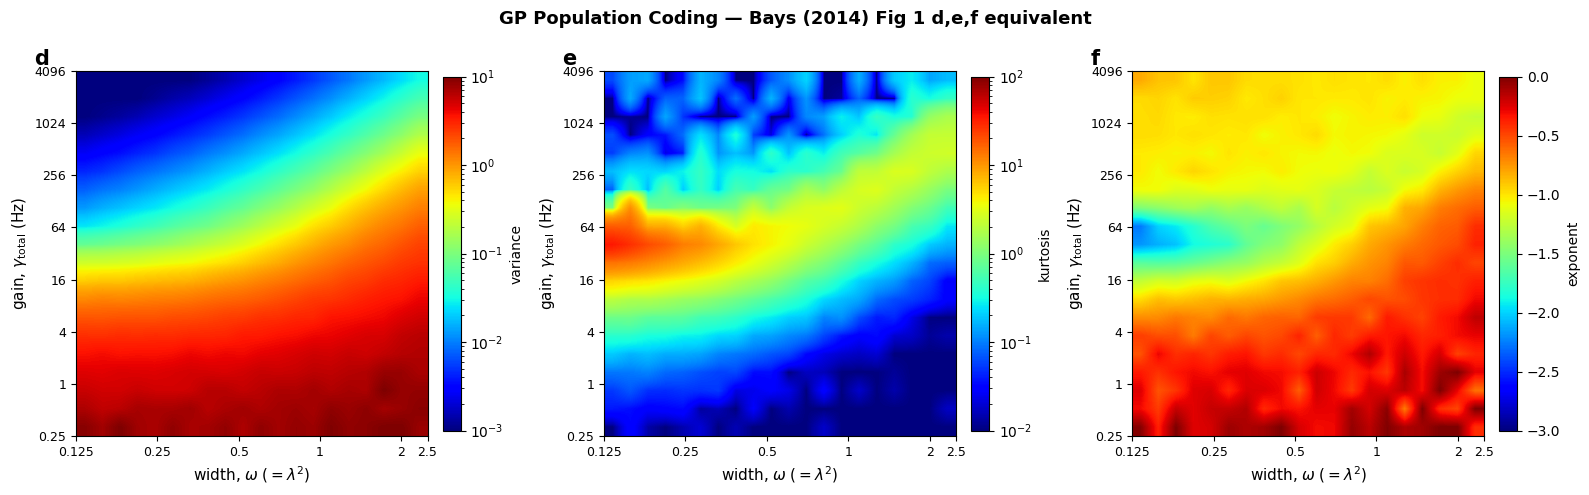

Variance range:  [0.0004, 12.1095]
Kurtosis range:  [-0.1363, 34.0826]
Exponent range:  [-2.2635, 0.3947]


In [9]:
# No flip needed: lambdas go small→large, omegas = lambdas² also go small→large
# This matches Bays's x-axis (ω increasing left→right)
var_plot = variance_grid
kur_plot = kurtosis_grid
exp_plot = exponent_grid

# Image extent in log2 coordinates
ext = [
    np.log2(omegas[0]),          # x-left  = smallest ω
    np.log2(omegas[-1]),         # x-right = largest ω
    np.log2(gammas_total[0]),    # y-bottom = smallest γ_total
    np.log2(gammas_total[-1]),   # y-top    = largest γ_total
]


def fmt_ax(ax, label):
    # x-axis: ω ticks
    ax.set_xlabel(r'width, $\omega\;(= \lambda^2)$', fontsize=11)
    omega_ticks = np.array([0.125, 0.25, 0.5, 1, 2, 2.5])
    omega_ticks = omega_ticks[(omega_ticks >= omegas[0] * 0.9) &
                              (omega_ticks <= omegas[-1] * 1.1)]
    ax.set_xticks(np.log2(omega_ticks))
    ax.set_xticklabels([f'{v:g}' for v in omega_ticks], fontsize=9)

    # y-axis: γ_total ticks
    ax.set_ylabel(r'gain, $\gamma_{\mathrm{total}}$ (Hz)', fontsize=11)
    gamma_ticks = np.array([0.25, 1, 4, 16, 64, 256, 1024, 4096])
    gamma_ticks = gamma_ticks[(gamma_ticks >= gammas_total[0] * 0.9) &
                              (gamma_ticks <= gammas_total[-1] * 1.1)]
    ax.set_yticks(np.log2(gamma_ticks))
    ax.set_yticklabels([f'{v:g}' for v in gamma_ticks], fontsize=9)

    # Panel label
    ax.text(-0.12, 1.06, f'$\\mathbf{{{label}}}$',
            transform=ax.transAxes, fontsize=15, fontweight='bold', va='top')


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Panel d: Variance ---
im0 = axes[0].imshow(
    np.clip(var_plot, 0.001, 10),
    origin='lower', aspect='auto', extent=ext,
    norm=mcolors.LogNorm(vmin=0.001, vmax=10),
    cmap='jet', interpolation='bilinear')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04).set_label('variance')
fmt_ax(axes[0], 'd')

# --- Panel e: Kurtosis ---
im1 = axes[1].imshow(
    np.clip(kur_plot, 0.01, 100),
    origin='lower', aspect='auto', extent=ext,
    norm=mcolors.LogNorm(vmin=0.01, vmax=100),
    cmap='jet', interpolation='bilinear')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04).set_label('kurtosis')
fmt_ax(axes[1], 'e')

# --- Panel f: Exponent ---
im2 = axes[2].imshow(
    np.clip(exp_plot, -3, 0),
    origin='lower', aspect='auto', extent=ext,
    vmin=-3, vmax=0,
    cmap='jet', interpolation='bilinear')
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04).set_label('exponent')
fmt_ax(axes[2], 'f')

fig.suptitle('GP Population Coding — Bays (2014) Fig 1 d,e,f equivalent',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('bays_fig1_def_corrected.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Variance range:  [{np.nanmin(variance_grid):.4f}, {np.nanmax(variance_grid):.4f}]")
print(f"Kurtosis range:  [{np.nanmin(kurtosis_grid):.4f}, {np.nanmax(kurtosis_grid):.4f}]")
print(f"Exponent range:  [{np.nanmin(exponent_grid):.4f}, {np.nanmax(exponent_grid):.4f}]")

### TODO:

1. Set Sizes above 1.